In [3]:
import pandas as pd


In [13]:
import os

print("Current Working Directory:")
print(os.getcwd())

print("\nFiles and Folders:")
print(os.listdir())

print(os.listdir(".."))



print(os.listdir("../data"))

Current Working Directory:
C:\Users\Sahana R\Retail_Data_Engineering\Code

Files and Folders:
['.ipynb_checkpoints', 'Retail_Data_Engineering.ipynb']
['.ipynb_checkpoints', 'anaconda_projects', 'Code', 'Dashboard', 'data', 'Document', 'output', 'retail.db']
['USECASE - Data Engineering.xlsx']


DATA INGESTION

In [15]:
#Load Data
file_path = r"../data/USECASE - Data Engineering.xlsx"

excel_file = pd.ExcelFile(file_path)

print(excel_file.sheet_names)

['product_details', 'retail_data1', 'retail_data2']


In [17]:
products = pd.read_excel(
    file_path,
    sheet_name="product_details"
)

retail1 = pd.read_excel(
    file_path,
    sheet_name="retail_data1"
)

retail2 = pd.read_excel(
    file_path,
    sheet_name="retail_data2"
)

print(products.shape)
print(retail1.shape)
print(retail2.shape)

(10, 4)
(4243, 16)
(4251, 16)


In [19]:
#Combine Retail Data
retail = pd.concat(
    [retail1, retail2],
    ignore_index=True
)

print(retail.shape)
retail.head()

(8494, 16)


,transaction_id,customer_id,customer_name,product_id,price,product_name,category,purchase_location,city,transaction_date,quantity,payment_method,discount,email,phone,payment_status
0,1,642,Troy Mitchell,108,15000.0,Mixer grinder,Home Appliances,offline,Bangalore,2025-12-06 00:00:00,3,UPI,0.10,Troy60@gmail.com,8385276968,successful
1,2,881,Sarah Guerrero,102,70000.0,Phone,ELEC,online,Bangalore,2025-07-21 00:00:00,5,Card,0.35,SarahGuerrero@yahoo.com,7147248911,successful
2,3,505,Samantha Hull,109,65000.0,Refrigerator,Home Appliances,offline,Chennai,2025-07-11 00:00:00,2,UPI,0.05,SamanthaHull@outlook.com,7415321565,successful
3,4,794,Gerald Cooper,106,80000.0,sofa,FURN,offline,Chennai,2025-10-06 00:00:00,2,UPI,0.05,GeraldCooper@gmail.com,9739354201,successful
4,5,864,Cameron Black,108,15000.0,Mixer grinder,home appliances,offline,Chennai,2025-12-12 00:00:00,1,Cash,0.05,CameronBlack@yahoo.com,9938169477,successful


DATA CLEANING

In [21]:
# Check missing values
print("\nMissing Values:")
print(retail.isnull().sum())


Missing Values:
transaction_id         0
customer_id            0
customer_name          0
product_id             0
price                809
product_name           0
category               0
purchase_location      0
city                   0
transaction_date       0
quantity               0
payment_method         0
discount               0
email                  0
phone                  0
payment_status         0
dtype: int64


In [23]:
#Check full dupliacte rows
print("\nFull Duplicate Rows:")
print(retail.duplicated().sum())


Full Duplicate Rows:
0


In [25]:
#Check Categories
print("\nUnique Categories:")
print(retail["category"].unique())


Unique Categories:
['Home Appliances' 'ELEC' 'FURN' 'home appliances' 'Electronics'
 'electronics' 'CLOTH' 'clothing' 'Clothing' 'furniture' 'Furniture'
 'HOME']


In [27]:
#Standardize Category Values
category_map = {
    "electronics":"Electronics",
    "ELEC":"Electronics",

    "furniture":"Furniture",
    "FURN":"Furniture",

    "home appliances":"Home Appliances",
    "HOME":"Home Appliances",

    "clothing":"Clothing",
    "CLOTH":"Clothing"
}

retail["category"] = retail["category"].replace(category_map)

print("\nCategories After Cleaning:")
print(retail["category"].unique())


Categories After Cleaning:
['Home Appliances' 'Electronics' 'Furniture' 'Clothing']


In [29]:
#Check Product Names
print("\nUnique Product Names:")
print(retail["product_name"].unique())


Unique Product Names:
['Mixer grinder' 'Phone' 'Refrigerator' 'sofa' 'laptop' 'phone'
 'Microwave' 'PHONE' 'Shoes' 'SOFA' 'REFRIGERATOR' 'refrigerator' 'SHOES'
 'SHIRT' 'Tv' 'DINING TABLE' 'dining table' 'MICROWAVE' 'Shirt' 'shirt'
 'TV' 'shoes' 'Laptop' 'tv' 'MIXER GRINDER' 'microwave' 'mixer grinder'
 'Dining table' 'Sofa' 'LAPTOP']


In [31]:
#Standardize Product Names
retail["product_name"] = (
    retail["product_name"]
    .str.title()
)

print("\nProduct Names After Cleaning:")
print(retail["product_name"].unique())


Product Names After Cleaning:
['Mixer Grinder' 'Phone' 'Refrigerator' 'Sofa' 'Laptop' 'Microwave'
 'Shoes' 'Shirt' 'Tv' 'Dining Table']


In [33]:
#Check Date Formats
print("\nUnique Date Formats:")
print(retail["transaction_date"].head(20))


Unique Date Formats:
0     2025-12-06 00:00:00
1     2025-07-21 00:00:00
2     2025-07-11 00:00:00
3     2025-10-06 00:00:00
4     2025-12-12 00:00:00
5     2025-07-25 00:00:00
6     2025-07-25 00:00:00
7     2026-03-03 00:00:00
8              02-19-2026
9     2025-08-30 00:00:00
10    2025-12-16 00:00:00
11    2025-12-15 00:00:00
12             06-30-2025
13    2025-06-14 00:00:00
14    2026-02-24 00:00:00
15    2026-01-31 00:00:00
16             08-20-2025
17    2025-05-19 00:00:00
18             05-15-2025
19    2025-09-07 00:00:00
Name: transaction_date, dtype: object


In [35]:
#Fix Date Formats
retail["transaction_date"] = pd.to_datetime(
    retail["transaction_date"],
    errors="coerce"
)

print("\nInvalid Dates:")
print(retail["transaction_date"].isnull().sum())


Invalid Dates:
0


In [37]:
#Check Product Master Sheet
products = pd.read_excel(file_path,sheet_name="product_details")
print("\nProduct Master Sheet:")
print(products.head())
print(products.columns)
print(products.shape)


Product Master Sheet:
   product_id product_name     category   price
0         101       Laptop  Electronics  250000
1         102        Phone  Electronics   70000
2         103        Shirt     Clothing    1300
3         104        Shoes     Clothing    8000
4         105           TV  Electronics   45000
Index(['product_id', 'product_name', 'category', 'price'], dtype='object')
(10, 4)


In [39]:
# Revenue Calculation
retail["revenue"] = (
    retail["price"]
    * retail["quantity"]
    * (1 - retail["discount"])
)

print("\nRevenue Sample:")
print(
    retail[ 
        ["price","quantity","discount","revenue"]
    ].head()
)


Revenue Sample:
     price  quantity  discount   revenue
0  15000.0         3      0.10   40500.0
1  70000.0         5      0.35  227500.0
2  65000.0         2      0.05  123500.0
3  80000.0         2      0.05  152000.0
4  15000.0         1      0.05   14250.0


In [41]:
#Create Time Features
retail["year"] = retail["transaction_date"].dt.year
retail["month"] = retail["transaction_date"].dt.month
retail["quarter"] = retail["transaction_date"].dt.quarter

print("\nTime Features:")
print(
    retail[
        ["transaction_date","year","month","quarter"]
    ].head()
)


Time Features:
  transaction_date  year  month  quarter
0       2025-12-06  2025     12        4
1       2025-07-21  2025      7        3
2       2025-07-11  2025      7        3
3       2025-10-06  2025     10        4
4       2025-12-12  2025     12        4


In [43]:
# PII Masking

retail["email"] = retail["email"].apply(
    lambda x: x[:2] + "***@" + x.split("@")[1]
)

retail["phone"] = retail["phone"].astype(str).apply(
    lambda x: "******" + x[-4:]
)

print("\nPII Masking Completed")


PII Masking Completed


In [45]:
#Save Dataset
import os
os.makedirs("output", exist_ok=True)

retail.to_csv(
    "output/cleaned_data.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


DATA VALIDATION


In [48]:
df = pd.read_csv("output/cleaned_data.csv")

In [50]:
print("Invalid Prices:")
print((df["price"] <= 0).sum())


Invalid Prices:
0


In [52]:
print("Invalid Quantities:")
print((df["quantity"] <= 0).sum())


Invalid Quantities:
93


In [54]:
# Show invalid quantity records

invalid_qty = df[df["quantity"] <= 0]

print("\nInvalid Quantity Records:")
print(invalid_qty.head(10))


Invalid Quantity Records:
     transaction_id  customer_id       customer_name  product_id     price  \
33               33           50    Stacey Henderson         104    8000.0   
75               74          907      Jeffrey Mccall         102   70000.0   
77               76          335         Jacob Evans         103    1300.0   
78               77          780    Elizabeth Miller         110       NaN   
100              97          723  Christopher Walter         106   80000.0   
139             133          633       Julie Jackson         103    1300.0   
356             339          758       Nichole Jones         108   15000.0   
661             624          925         Steve Ayala         101  250000.0   
714             674          826           Ryan Wade         102   70000.0   
893             841          725       Jody Martinez         105   45000.0   

      product_name         category purchase_location       city  \
33           Shoes         Clothing           

In [56]:
print("Invalid Discounts:")
print(
    ((df["discount"] < 0) |
     (df["discount"] > 1)).sum()
)

Invalid Discounts:
0


In [58]:
print("Duplicate Transaction IDs:")
print(
    df.duplicated(
        subset=["transaction_id"]
    ).sum()
)

Duplicate Transaction IDs:
494


In [60]:
# Show duplicate transaction records
duplicate_txn = df[
    df.duplicated(
        subset=["transaction_id"],
        keep=False
    )
]

print("\nDuplicate Transaction Records:")
print(
    duplicate_txn[
        ["transaction_id",
         "customer_id",
         "product_name",
         "quantity",
         "revenue"]
    ].head(20)
)


Duplicate Transaction Records:
     transaction_id  customer_id  product_name  quantity   revenue
5                 6          181        Laptop         5  812500.0
6                 6          181        Laptop         5  812500.0
57               57           72            Tv         5  180000.0
58               57           72            Tv         5  180000.0
83               82          578        Laptop         4  600000.0
84               82          578        Laptop         4  600000.0
86               84          379            Tv         5  180000.0
87               84          379            Tv         5  180000.0
129             126           17        Laptop         1  212500.0
130             126           17        Laptop         1  212500.0
131             127          115        Laptop         1  150000.0
132             127          115        Laptop         1  150000.0
135             130          149         Shirt         1    1105.0
136             130          1

In [62]:
df.to_csv(
    "output/transformed_data.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [64]:
from sqlalchemy import create_engine

engine = create_engine("sqlite:///retail.db")

retail.to_sql(
    "retail_sales",
    engine,
    if_exists="replace",
    index=False
)

print("Data loaded successfully!")

Data loaded successfully!


In [66]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("retail.db")

queries = {
    "Total Revenue": """
        SELECT SUM(revenue) AS total_revenue
        FROM retail_sales
    """,

    "Revenue by Category": """
        SELECT category,
               SUM(revenue) AS revenue
        FROM retail_sales
        GROUP BY category
    """,

    "Revenue by City": """
        SELECT city,
               SUM(revenue) AS revenue
        FROM retail_sales
        GROUP BY city
    """,

    "Top 10 Products": """
        SELECT product_name,
               SUM(revenue) AS revenue
        FROM retail_sales
        GROUP BY product_name
        ORDER BY revenue DESC
        LIMIT 10
    """,

    "Monthly Revenue": """
        SELECT month,
               SUM(revenue) AS revenue
        FROM retail_sales
        GROUP BY month
        ORDER BY month
    """
}

for title, query in queries.items():
    print("\n" + "=" * 50)
    print(title)
    print(pd.read_sql_query(query, conn))

conn.close()


Total Revenue
   total_revenue
0   1.117671e+09

Revenue by Category
          category      revenue
0         Clothing   16245950.0
1      Electronics  655292500.0
2        Furniture  228792000.0
3  Home Appliances  217341000.0

Revenue by City
        city      revenue
0  Bangalore  208588525.0
1    Chennai  228996470.0
2      Delhi  232613465.0
3  Hyderabad  224688305.0
4     Mumbai  222784685.0

Top 10 Products
    product_name      revenue
0         Laptop  457737500.0
1           Sofa  137572000.0
2          Phone  119430500.0
3   Refrigerator  111559500.0
4   Dining Table   91220000.0
5      Microwave   80187750.0
6             Tv   78124500.0
7  Mixer Grinder   25593750.0
8          Shoes   14044400.0
9          Shirt    2201550.0

Monthly Revenue
    month      revenue
0       1   92232375.0
1       2   94900580.0
2       3   87225625.0
3       4   89521035.0
4       5   88968420.0
5       6   97718775.0
6       7   94358225.0
7       8  102741540.0
8       9   93517280.0
9  

EDA


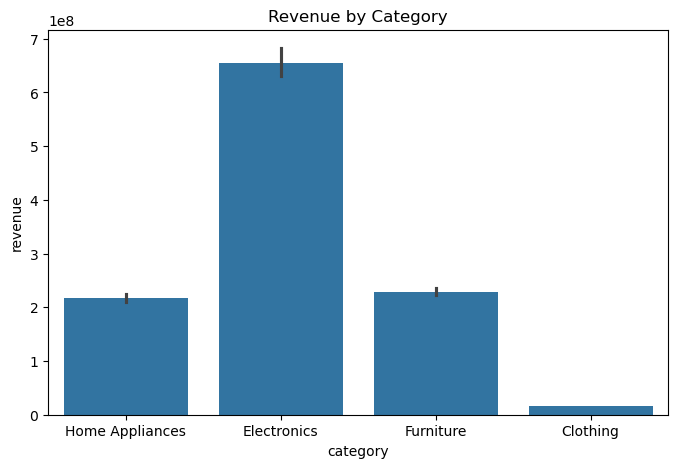

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=retail,
    x="category",
    y="revenue",
    estimator=sum
)

plt.title("Revenue by Category")
plt.show()

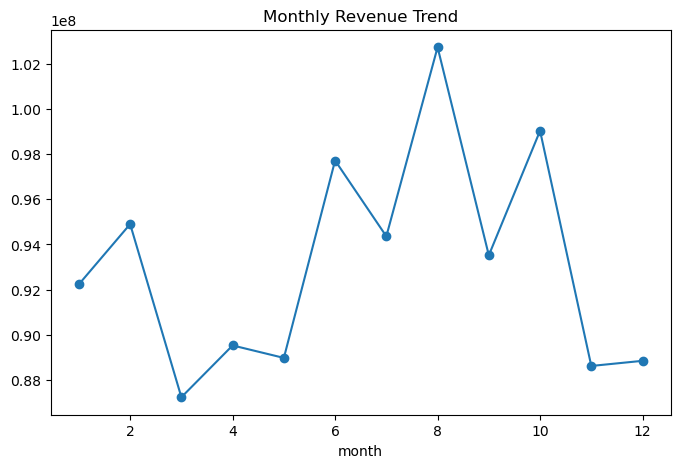

In [70]:
monthly = retail.groupby("month")["revenue"].sum()

plt.figure(figsize=(8,5))

monthly.plot(marker="o")

plt.title("Monthly Revenue Trend")
plt.show()

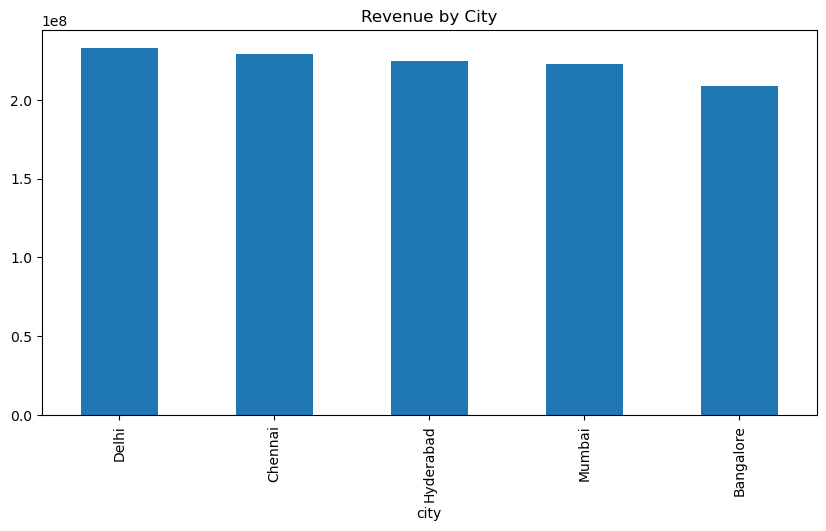

In [71]:
city_revenue = retail.groupby("city")["revenue"].sum()

city_revenue.sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Revenue by City")
plt.show()

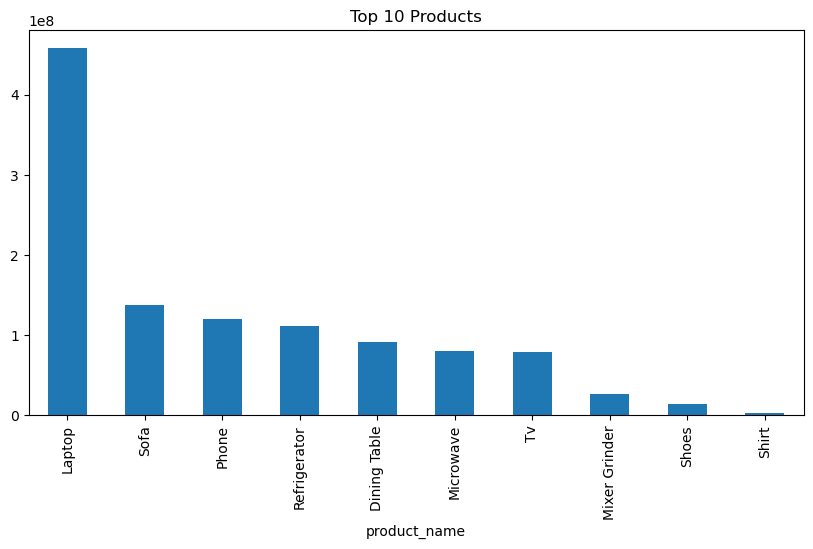

In [72]:
top_products = (
    retail.groupby("product_name")["revenue"]
          .sum()
          .sort_values(ascending=False)
          .head(10)
)

top_products.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Products")
plt.show()